# Toy example to check KL div loss

In [20]:
import numpy as np
import os
import torch
from sklearn.cluster import KMeans
from torch.nn import KLDivLoss
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import wandb
from scipy.stats import pearsonr

from nnfabrik.utility.nn_helpers import set_random_seed
from sklearn.cluster import AgglomerativeClustering


seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 1
#torch.cuda.set_device(f"cuda:{cuda_number}")
device = f'cuda:{cuda_number}'
#device = 'cpu'

In [21]:
cluster_number=2
dec_starting_epoch=30
alpha=1.0
kmeans_init=20
base_multiplier=4e3
exponent=1.2
data_spread = 5

In [22]:
np.random.seed(seed)
torch.manual_seed(50)
n_samples = 1100
n_neurons = 1000
dim = 128
seed = 42

white_noise = torch.from_numpy(np.random.normal(loc=0.0, scale=1.0, size=(n_samples, dim)).astype(np.float32))  

In [23]:
# create weights/RFs of two types drawn from 2 multivariate Gausians

mean_0 = 1.5* torch.ones(dim, dtype=torch.float32)
mean_1 = torch.ones(dim, dtype=torch.float32)
cov = torch.eye(dim, dtype=torch.float32)

dist_0 = torch.distributions.MultivariateNormal(loc=mean_0, covariance_matrix=cov)
dist_1 = torch.distributions.MultivariateNormal(loc=mean_1, covariance_matrix=cov)

samples_0 = dist_0.sample((700,))  # shape: (3500, 128)
samples_1 = dist_1.sample((300,))  # shape: (3500, 128)

weights = torch.cat([samples_0, samples_1], dim=0)  # shape: (1000, 128)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

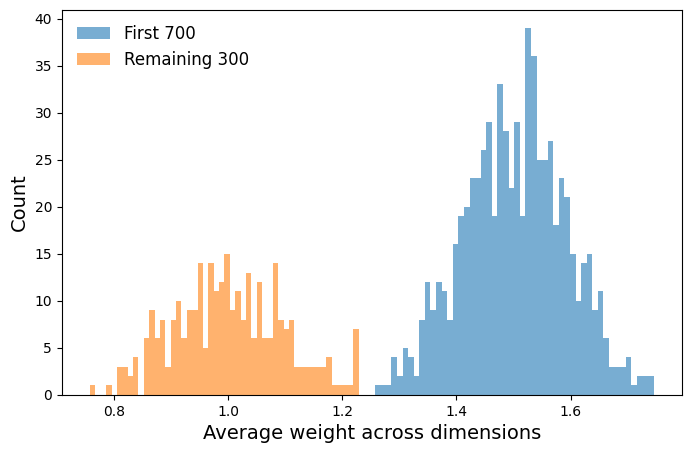

In [24]:
avg_first = weights[:700, :].mean(axis=1).numpy()
avg_rest = weights[700:, :].mean(axis=1).numpy()

# Plot histogram of the averages
plt.figure(figsize=(8, 5))
plt.hist(avg_first, bins=50, alpha=0.6, label='First 700', color='C0')
plt.hist(avg_rest, bins=50, alpha=0.6, label='Remaining 300', color='C1')

plt.xlabel('Average weight across dimensions', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout

In [25]:
responses_clean = weights @ white_noise.T  # shape: (n_neurons, n_images)
signal_variance = responses_clean.var()  
desired_snr = 5   

snrs = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
#snrs = [10]
responses_noisy = []
for snr in snrs:
    noise_variance = signal_variance / snr
    noise = torch.randn_like(responses_clean) * noise_variance.sqrt()
    response_noisy = responses_clean + noise  # shape: (n_neurons, n_images)
    response_noisy = response_noisy.T  # shape: (n_images, n_neurons)
    responses_noisy.append(response_noisy)

In [26]:
# simple linear model
import torch.nn as nn
class SimpleNN(nn.Module):
    def __init__(self, input_dim, output_dim=500):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  # Directly define the layer

    def forward(self, x):
        return self.linear(x)  # No need for Sequential

In [27]:
def update_alpha(resp, u, alpha, max_iter=10, tol=1e-4):
    'updates alpha when maximizing the log likelihood with newton method'
    for _ in range(max_iter):
        f_alpha = -torch.sum(
                resp * (1 + (torch.log(u) - u) + torch.special.digamma(alpha / 2) - torch.log(alpha/ 2))
            )
        f_prime_alpha = (1 / alpha) - (0.5 * torch.special.polygamma(1, alpha / 2))  # Trigamma function

        alpha_new = alpha - f_alpha / f_prime_alpha  # Newton-Raphson update


        # Ensure alpha stays in a valid range
        alpha_new = torch.clamp(alpha_new, min=0.01, max=100)

        if torch.abs(alpha_new - alpha) < tol:
            break

        alpha = alpha_new.detach()
    return alpha

In [28]:
def soft_assignments_mult(encoded_features, cluster_centers, sigma, alpha=1, p=1):
    sigma_inv = 1.0 / sigma  #
    diff = encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)  
    norm_sigma = torch.sum(diff * sigma_inv*diff, dim=2) 
    det = torch.sum(torch.log(sigma), dim=1) 
    log_gamma_top = torch.lgamma((alpha + p) / 2)
    log_gamma_bottom = torch.lgamma(alpha / 2)
    log_pdf = (
        log_gamma_top - log_gamma_bottom
        - 0.5 * det
        - (p / 2) * torch.log(alpha * torch.pi)
        - ((alpha + p) / 2) * torch.log(1 + (norm_sigma / alpha))
    )

    log_assignments = log_pdf - torch.logsumexp(log_pdf , dim=1, keepdim=True)

    return torch.exp(log_assignments)  
  
def target_distribution(batch: torch.Tensor, exponent=exponent) -> torch.Tensor:
    weight = (batch**exponent) / torch.sum(batch, 0)
    return (weight.t() / torch.sum(weight, 1)).t()

def EM_t_mult(features, resp, cluster_centers, sigma, alpha, d=1):
    sigma_inv = 1.0 / sigma  # (K,)
    diff = (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0))
    norm_sigma = torch.sum((diff **2 * sigma_inv),2)  
    u = ((alpha + d)/(alpha +norm_sigma)).detach()  
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    cluster_centers = numerator/denominator

    weighted_sq_diff = resp.unsqueeze(2)* u.unsqueeze(2) * (diff ** 2)  # (N, K, D)
    numerator = weighted_sq_diff.sum(dim=0) #(K,D)
    denominator = torch.sum(resp, dim=0, keepdim=True)  # (K,)
    sigma = (numerator / denominator.T).detach() 
    return cluster_centers, sigma

In [29]:
def EM_t_1D(features, resp, cluster_centers, taus, alpha, d=1):
    norm_squared = torch.sum(
    (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, dim=2
    )  
    u = (alpha + d)/(alpha +norm_squared*(taus**(-1)))  
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    cluster_centers = numerator/denominator

    weighted_sums = torch.sum(resp* u * norm_squared, dim=0) 
    taus = (weighted_sums / torch.sum(resp, dim=0, keepdim=True)).detach()
    return cluster_centers, taus


def soft_assignments_1D(encoded_features, cluster_centers, tau, alpha=1, p=1):
    norm_squared = torch.sum(
        (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, 2
    )
    assignments = 1.0 / (1.0 + (norm_squared / (alpha * tau)))
    assignments = (assignments ** ((alpha + p) / 2))/(tau**1/2)
    #print('Assignments shape', assignments.shape)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

In [31]:
def trainer(model, dataloader, cluster_number=cluster_number, kmeans_init=10, 
            dec_starting_epoch=dec_starting_epoch,
            use_diag_cov=True,
            learn_alpha=True,
            exponent=exponent, lr_init=0.008, epochs=100, device=device, alpha = 1.0):
    '''
    use_diag_conv: Bool that indicates wether to use a diagonal covariance matrix or just one value for each cluster
    '''
    MSE_losse = []
    patience = 40
    patience_counter = 0
    best_corr=0
    if learn_alpha:
        alpha = torch.nn.Parameter(torch.tensor(1.0, device=device, requires_grad=True))
        optimizer = torch.optim.Adam(list(model.parameters()) + [alpha], lr=lr)
    else:
        alpha = torch.tensor(alpha, device=device, requires_grad=False)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr_init)
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch
    criterion = nn.MSELoss()

    from torch.optim.lr_scheduler import ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max',         # maximize Pearson correlation
        factor=0.5,         # halve the LR each time
        patience=20,        # wait 10 epochs with no improvement
        verbose=True,
        min_lr=1e-6
    )
    model.to(device)
    model.train()
    for epoch in range(epochs):

        epoch_loss = 0
        epoch_kldiv_loss = 0
        epoch_loss_main = 0
        
        if epoch == dec_starting_epoch:
            cluster_centers_list = []
            features = model.linear.weight.data.detach().cpu().numpy()
            kmeans = KMeans(
                n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
            )
            with torch.no_grad():
                predicted = kmeans.fit_predict(features)

            cluster_centers = torch.tensor(
                kmeans.cluster_centers_, dtype=torch.float, device=device, requires_grad=True,
            )
            
            #print('cluster centers', cluster_centers)
            if use_diag_cov:
                p = features.shape[1]
                sigma = torch.zeros((cluster_number,p), device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device) 
                    if len(cluster_points) > 0:
                        sigma[k] = torch.var(cluster_points, dim=0, unbiased=True) +1e-6

            else: 
                sigma = torch.zeros(cluster_number, device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device)  
                    if len(cluster_points) > 0:
                        sigma[k] = torch.mean(torch.sum((cluster_points - cluster_centers[k])**2,1))
                sigma = sigma.unsqueeze(0)
                #print('Tau beginning', sigma)
                p=1
            print('Sigma beginning: ', sigma)
            if learn_alpha:
                alpha.data = torch.tensor(1.0, dtype=torch.float, device=device)

            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            
            kmeans = KMeans(n_clusters=cluster_number, n_init=10, random_state=42)

        for i, (inputs, labels) in enumerate(dataloader['train']): 
            inputs = inputs.to(device)     
            labels = labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() 
            
            #if epoch >= dec_starting_epoch:
            #    loss = torch.zeros(1, device=device)
            
            epoch_loss += loss.detach()
            epoch_loss_main += loss.detach() 
            if epoch >= dec_starting_epoch:
                features = model.linear.weight.T
                if use_diag_cov:
                    q = soft_assignments_mult(features, cluster_centers, sigma, alpha,p)
                else:
                    q = soft_assignments_1D(features, cluster_centers, sigma, alpha,p)

                q =q.clamp(min =1e-10)

                target = target_distribution(q, exponent)
                target = target.clamp(min=1e-10)
                kldiv_loss =  kl_multiplier * kldiv_criterion(q.log(), target)
                
                target = target.clamp(min=1e-10)
                kldiv_loss.backward()
                epoch_kldiv_loss += kldiv_loss.detach()
                epoch_loss += kldiv_loss.detach()
                if use_diag_cov:
                    cluster_centers, sigma = EM_t_mult(features, q, cluster_centers, sigma, alpha, p)
                else:
                    cluster_centers, sigma = EM_t_1D(features, q, cluster_centers, sigma, alpha, p)
                with torch.no_grad():
                    cluster_centers_np = cluster_centers.cpu().detach().numpy()
                    cluster_centers_list.append(cluster_centers_np)
            optimizer.step()  
            optimizer.zero_grad()   

        if epoch == dec_starting_epoch -1:
            print('Loss at dec starting epoch', epoch_loss_main)
            kl_multiplier = epoch_loss/1000
            MSE_losse.append(epoch_loss.cpu().numpy())
            

        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for inputs, labels in dataloader['test']:
                inputs = inputs.to(device)
                labels = labels.to(device)
                preds = model(inputs)
                all_preds.append(preds)
                all_targets.append(labels)

        pred_cat = torch.cat(all_preds, dim=0).cpu().numpy()
        target_cat = torch.cat(all_targets, dim=0).cpu().numpy()
        corrs = [
            (pearsonr(pred_cat[:, j], target_cat[:, j])[0])
            for j in range(pred_cat.shape[1])
        ]
        avg_corr = sum((corrs)) / len(corrs)
        scheduler.step(avg_corr)  

        # --- Early Stopping ---
        if avg_corr > best_corr + 1e-4:
            best_corr = avg_corr
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Stopping early at epoch {epoch} (no improvement for {patience} epochs).")
            break

    print("Training Complete!")
    model.eval()
    features = model.linear.weight.data.detach()
    if use_diag_cov:
        q = soft_assignments_mult(features.T, cluster_centers, sigma, alpha,p)
    else:
        q = soft_assignments_1D(features.T, cluster_centers, sigma, alpha,p)

    all_preds = []
    all_labels = []
    MSE_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader['train']:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            all_preds.append(outputs.cpu())
            all_labels.append(labels.cpu())
            MSE_loss += criterion(outputs, labels).item()

    MSE_losse.append(MSE_loss)
    features = (features).cpu().numpy()
    predictions = (q).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)
    return features, predictions, cluster_centers_np, MSE_losse, avg_corr

In [32]:
def trainer_DEC(model, dataloader, cluster_number=cluster_number, kl_multiplier = 1, kmeans_init=10, 
            dec_starting_epoch=dec_starting_epoch,
            use_diag_cov=True,
            learn_alpha=True,
            exponent=exponent, lr_init=0.008, epochs=100, device=device, alpha = 1.0):
    '''
    use_diag_conv: Bool that indicates wether to use a diagonal covariance matrix or just one value for each cluster
    '''
    patience = 40
    patience_counter = 0
    best_corr=0
    MSE_losse = []
    p = model.linear.in_features
    cluster_centers = torch.nn.Parameter(
        torch.zeros(
            cluster_number,
            p,
            dtype=torch.float,
            device=device,
        ),
        requires_grad=True,
    )  
    if learn_alpha:
        alpha = torch.nn.Parameter(torch.tensor(1.0, device=device, requires_grad=True))
        optimizer = torch.optim.Adam(
            list(model.parameters())
            + [cluster_centers] + [alpha]+ [sigma],  # Combine model params and additional tensor
            lr=lr_init
            )
    else:
        alpha = torch.tensor(alpha, device=device, requires_grad=False)
        optimizer = torch.optim.AdamW(
            list(model.parameters())
            + [cluster_centers] ,  # Combine model params and additional tensor
            lr=lr_init,
            )
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch
    criterion = nn.MSELoss()

    from torch.optim.lr_scheduler import ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max',         # maximize Pearson correlation
        factor=0.5,         # halve the LR each time
        patience=20,        # wait 10 epochs with no improvement
        verbose=True,
        min_lr=1e-6
    )

    model.to(device)
    model.train()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_kldiv_loss = 0
        epoch_loss_main = 0

        if epoch == dec_starting_epoch:
            cluster_centers_list = []
            features = model.linear.weight.data.detach().cpu().numpy()
            kmeans = KMeans(
                n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
            )
            with torch.no_grad():
                predicted = kmeans.fit_predict(features)

            cluster_centers.data = torch.tensor(
                kmeans.cluster_centers_, dtype=torch.float, device=device
            )
            mixing_coefficient = torch.ones(cluster_number, device=device) / cluster_number 
            if use_diag_cov:
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device) 
                    if len(cluster_points) > 0:
                        sigma[k].data.copy_(torch.var(cluster_points, dim=0, unbiased=True) + 1e-6)
                print('Within cluster variance ', sigma)
            else: 
                sigma=1
                p=1
            if learn_alpha:
                alpha.data = torch.tensor(1.0, dtype=torch.float, device=device)

            #print('Sigma beginning', sigma)
            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            
            kmeans = KMeans(n_clusters=cluster_number, n_init=10, random_state=42)
    

        for i, (inputs, labels) in enumerate(dataloader['train']): 
            #if epoch < dec_starting_epoch:
            inputs = inputs.to(device)     
            labels = labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() 

            epoch_loss += loss.detach()
            epoch_loss_main += loss.detach() 
            if epoch >= dec_starting_epoch:
                features = model.linear.weight.T

                if use_diag_cov:
                    q = soft_assignments_mult(features, cluster_centers, sigma, alpha,p)
                else:
                    q = soft_assignments_1D(features, cluster_centers, sigma, alpha,p)

                target = target_distribution(q, exponent)
                target = target.clamp(min=1e-10)
                q = q.clamp(min=1e-10)
                    
                kldiv_loss = kl_multiplier* kldiv_criterion(q.log(), target)
  
                kldiv_loss.backward()

                epoch_kldiv_loss += kldiv_loss.detach()
                epoch_loss += kldiv_loss.detach()

                with torch.no_grad():
                    cluster_centers_np = cluster_centers.cpu().detach().numpy()
                    cluster_centers_list.append(cluster_centers_np)
            optimizer.step()  
            optimizer.zero_grad()   
        if epoch == dec_starting_epoch -1:
            print('Loss at dec starting epoch', epoch_loss_main)
            kl_multiplier = epoch_loss/1000
            MSE_losse.append(epoch_loss.cpu().numpy())
            

        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for inputs, labels in dataloader['test']:
                inputs = inputs.to(device)
                labels = labels.to(device)
                preds = model(inputs)
                all_preds.append(preds)
                all_targets.append(labels)

        pred_cat = torch.cat(all_preds, dim=0).cpu().numpy()
        target_cat = torch.cat(all_targets, dim=0).cpu().numpy()

        corrs = [
            (pearsonr(pred_cat[:, j], target_cat[:, j])[0])
            for j in range(pred_cat.shape[1])
        ]
        avg_corr = sum((corrs)) / len(corrs)
        scheduler.step(avg_corr) 

        if avg_corr > best_corr + 1e-4:
            best_corr = avg_corr
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Stopping early at epoch {epoch} (no improvement for {patience} epochs).")
            break

        
    print("Training Complete!")
    print(f"Best Pearson correlation: {best_corr:.4f}")
    model.eval()
    features = model.linear.weight.data.detach()
    if use_diag_cov:
        q = soft_assignments_mult(features.T, cluster_centers, sigma, alpha,p)
    else:
        q = soft_assignments_1D(features.T, cluster_centers, sigma, alpha,p)

    all_preds = []
    all_labels = []
    MSE_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader['train']:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            all_preds.append(outputs.cpu())
            all_labels.append(labels.cpu())
            MSE_loss += criterion(outputs, labels).item()


    MSE_losse.append(MSE_loss)
    features = (features).cpu().numpy()
    predictions = (q).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)
    return features, predictions, cluster_centers_np, MSE_losse, avg_corr

In [33]:
class WhiteNoiseDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]


In [ ]:
from sklearn.model_selection import train_test_split

features_DEC = []
predictions_DEC = []
cluster_centers_list_DEC = []
MSE_losses_DEC = []
best_corr_DEC = []
features_ours = []
predictions_ours = []
cluster_centers_list_ours = []
MSE_losses_ours = []
best_corr_ours = []


for i in range(len(snrs)):
    x_train, x_test, y_train, y_test = train_test_split(
        white_noise, responses_noisy[i], test_size=0.1, random_state=42
    )
    x_train = torch.tensor(x_train, dtype=torch.float32)
    x_test = torch.tensor(x_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    # Create Dataloaders
    dataloader = {
        'train': DataLoader(WhiteNoiseDataset(x_train, y_train), batch_size=256, shuffle=True),
        'test': DataLoader(WhiteNoiseDataset(x_test, y_test), batch_size=256, shuffle=False)
    }


    model = SimpleNN(input_dim=dim, output_dim=n_neurons)
    cluster_number=2
    feature_ours, prediction_ours, cluster_center_list_ours, MSE_ours, corr_ours = trainer(model, dataloader, dec_starting_epoch=30, 
                                                     cluster_number=cluster_number,
                                                      exponent=2, epochs=508, 
                                                      use_diag_cov=True, learn_alpha=False, alpha=2)
    print('Corr ours', corr_ours)

    model_DEC = SimpleNN(input_dim=dim, output_dim=n_neurons)
    feature_DEC, prediction_DEC, cluster_center_list_DEC, MSE_loss_DEC, corr_DEC = trainer_DEC(model_DEC, dataloader, dec_starting_epoch=30, 
                                                        cluster_number=cluster_number, kl_multiplier=10,
                                                        exponent=2, epochs=508, 
                                                        use_diag_cov=False, learn_alpha=False, alpha=2.1)
    print('Corr DEC', corr_DEC)
    features_DEC.append(feature_DEC)
    predictions_DEC.append(prediction_DEC)
    cluster_centers_list_DEC.append(cluster_center_list_DEC)
    best_corr_DEC.append(corr_DEC)

    MSE_losses_DEC.append(MSE_loss_DEC)   


    features_ours.append(feature_ours)
    predictions_ours.append(prediction_ours)
    cluster_centers_list_ours.append(cluster_center_list_ours)
    MSE_losses_ours.append(MSE_ours)
    best_corr_ours.append(corr_ours)


/tmp/ipykernel_915538/1841784178.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone

Loss at dec starting epoch tensor(1425232.2500, device='cuda:1')
Sigma beginning:  tensor([[0.1346, 0.1264, 0.1342, 0.1397, 0.1310, 0.1440, 0.1341, 0.1242, 0.1417,
         0.1362, 0.1372, 0.1333, 0.1223, 0.1346, 0.1335, 0.1380, 0.1360, 0.1440,
         0.1445, 0.1435, 0.1396, 0.1337, 0.1341, 0.1331, 0.1239, 0.1403, 0.1288,
         0.1473, 0.1379, 0.1345, 0.1361, 0.1398, 0.1393, 0.1298, 0.1288, 0.1391,
         0.1346, 0.1311, 0.1285, 0.1362, 0.1242, 0.1441, 0.1421, 0.1411, 0.1406,
         0.1387, 0.1288, 0.1341, 0.1394, 0.1340, 0.1280, 0.1346, 0.1283, 0.1224,
         0.1341, 0.1480, 0.1394, 0.1252, 0.1255, 0.1291, 0.1381, 0.1391, 0.1341,
         0.1177, 0.1307, 0.1349, 0.1353, 0.1418, 0.1265, 0.1303, 0.1317, 0.1488,
         0.1449, 0.1348, 0.1315, 0.1412, 0.1357, 0.1258, 0.1422, 0.1409, 0.1327,
         0.1359, 0.1386, 0.1442, 0.1353, 0.1283, 0.1270, 0.1400, 0.1320, 0.1405,
         0.1433, 0.1261, 0.1304, 0.1360, 0.1380, 0.1309, 0.1361, 0.1308, 0.1242,
         0.1438, 0.1247, 0

/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))
/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loss at dec starting epoch tensor(1424015.2500, device='cuda:1')
Stopping early at epoch 61 (no improvement for 40 epochs).
Training Complete!
Best Pearson correlation: 0.0018
Corr DEC 0.0014291593772327751


/tmp/ipykernel_915538/1841784178.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone

Loss at dec starting epoch tensor(141669.8906, device='cuda:1')
Sigma beginning:  tensor([[0.1744, 0.1775, 0.1809, 0.1883, 0.1750, 0.1731, 0.1702, 0.1872, 0.1696,
         0.1701, 0.1674, 0.1760, 0.1741, 0.1682, 0.1697, 0.1762, 0.1619, 0.1658,
         0.1705, 0.1757, 0.1641, 0.1659, 0.1797, 0.1716, 0.1675, 0.1748, 0.1789,
         0.1842, 0.1731, 0.1618, 0.1756, 0.1804, 0.1744, 0.1718, 0.1712, 0.1625,
         0.1675, 0.1724, 0.1740, 0.1722, 0.1833, 0.1765, 0.1560, 0.1627, 0.1701,
         0.1900, 0.1670, 0.1613, 0.1718, 0.1788, 0.1730, 0.1781, 0.1781, 0.1734,
         0.1792, 0.1648, 0.1615, 0.1665, 0.1689, 0.1769, 0.1663, 0.1694, 0.1745,
         0.1710, 0.1607, 0.1673, 0.1632, 0.1686, 0.1665, 0.1646, 0.1492, 0.1769,
         0.1743, 0.1696, 0.1805, 0.1760, 0.1805, 0.1585, 0.1679, 0.1665, 0.1749,
         0.1473, 0.1677, 0.1754, 0.1596, 0.1786, 0.1917, 0.1805, 0.1712, 0.1721,
         0.1657, 0.1642, 0.1761, 0.1751, 0.1830, 0.1760, 0.1773, 0.1662, 0.1578,
         0.1458, 0.1839, 0.

/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))
/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loss at dec starting epoch tensor(141678.5781, device='cuda:1')
Stopping early at epoch 73 (no improvement for 40 epochs).
Training Complete!
Best Pearson correlation: 0.0310
Corr DEC 0.031036905113646228


/tmp/ipykernel_915538/1841784178.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_915538/1841784178.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone

Loss at dec starting epoch tensor(28670.5195, device='cuda:1')
Sigma beginning:  tensor([[0.1513, 0.1574, 0.1559, 0.1564, 0.1764, 0.1788, 0.1634, 0.1555, 0.1656,
         0.1733, 0.1513, 0.1699, 0.1563, 0.1430, 0.1643, 0.1752, 0.1348, 0.1535,
         0.1762, 0.1556, 0.1574, 0.1692, 0.1618, 0.1682, 0.1729, 0.1552, 0.1722,
         0.1667, 0.1620, 0.1716, 0.1467, 0.1673, 0.1862, 0.1526, 0.1584, 0.1578,
         0.1845, 0.1513, 0.1579, 0.1636, 0.1580, 0.1696, 0.1752, 0.1577, 0.1532,
         0.1621, 0.1439, 0.1620, 0.1548, 0.1642, 0.1752, 0.1688, 0.1698, 0.1686,
         0.1438, 0.1603, 0.1624, 0.1608, 0.1861, 0.1465, 0.1797, 0.1635, 0.1647,
         0.1488, 0.1569, 0.1536, 0.1572, 0.1734, 0.1540, 0.1332, 0.1543, 0.1812,
         0.1481, 0.1714, 0.1973, 0.1655, 0.1618, 0.1605, 0.1602, 0.1557, 0.1634,
         0.1239, 0.1746, 0.1608, 0.1838, 0.1722, 0.1825, 0.1576, 0.1685, 0.1606,
         0.1683, 0.1543, 0.1655, 0.1504, 0.1635, 0.1547, 0.1465, 0.1540, 0.1641,
         0.1708, 0.1673, 0.1

Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 3.9512296 Differences dec: 0.00050685846
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 6.1368484 Differences dec: 1.0751501e-06
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 5.8663573 Differences dec: 5.6986264e-06
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 4.8116927 Differences dec: 8.973698e-07
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 5.9329653 Differences dec: 2.3150574e-06
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 5.691185 Differences dec: 5.4559823e-06
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 5.7108164 Differences dec: 1.1335681e-05
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 5.6519647 Differences dec: 9.533518e-06
Shape ours: (2, 128) Shape dec: (2, 128)
Differences ours: 5.6493006 Differences dec: 4.5457823e-06
Collected differences: [np.float32(3.9512296), np.float32(6.1368484), np.float32(5.8663573), np.float32

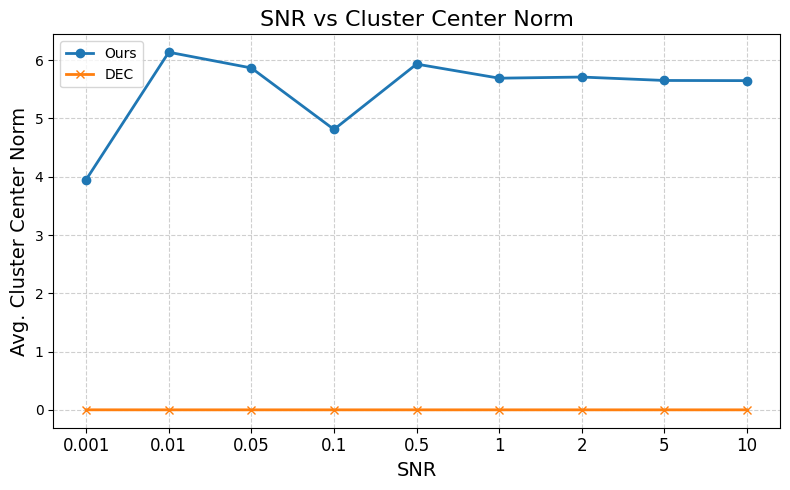

In [26]:
snrs = np.array(snrs)
differences_ours = []
differences_dec = []

for snr_idx in range(len(snrs)):
    centers_ours = cluster_centers_list_ours[snr_idx][-1]  # last center set at this SNR
    centers_dec = cluster_centers_list_DEC[snr_idx][-1]

    # Ensure shapes are (n_clusters, dim)
    print("Shape ours:", centers_ours.shape, "Shape dec:", centers_dec.shape)

    # Compute average L2 norm (or use axis=1 if shape is (n_clusters, dim))
    diff_ours = np.linalg.norm(centers_ours[0]- centers_ours[1])
    diff_dec = np.linalg.norm(centers_dec[0]- centers_dec[1])
    print("Differences ours:", diff_ours, "Differences dec:", diff_dec)

    differences_ours.append(diff_ours)
    differences_dec.append(diff_dec)

print('Collected differences:', (differences_ours))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(snrs)), differences_ours, marker='o', linewidth=2, label='Ours')
plt.plot(np.arange(len(snrs)), differences_dec, marker='x', linewidth=2, label='DEC')
#plt.xticks(snrs, fontsize=12)
plt.xticks(np.arange(len(snrs)), labels=[f"{snr:.2g}" for snr in snrs], fontsize=12)
plt.xlabel("SNR", fontsize=14)
plt.ylabel("Avg. Cluster Center Norm", fontsize=14)
plt.title("SNR vs Cluster Center Norm", fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Acc 0.509
Acc 0.509
Acc 0.562
Acc 0.757
Acc 0.926
Acc 0.94
Acc 0.942
Acc 0.934
Acc 0.934
Acc 0.51
Acc 0.686
Acc 0.701
Acc 0.655
Acc 0.623
Acc 0.616
Acc 0.705
Acc 0.7
Acc 0.643


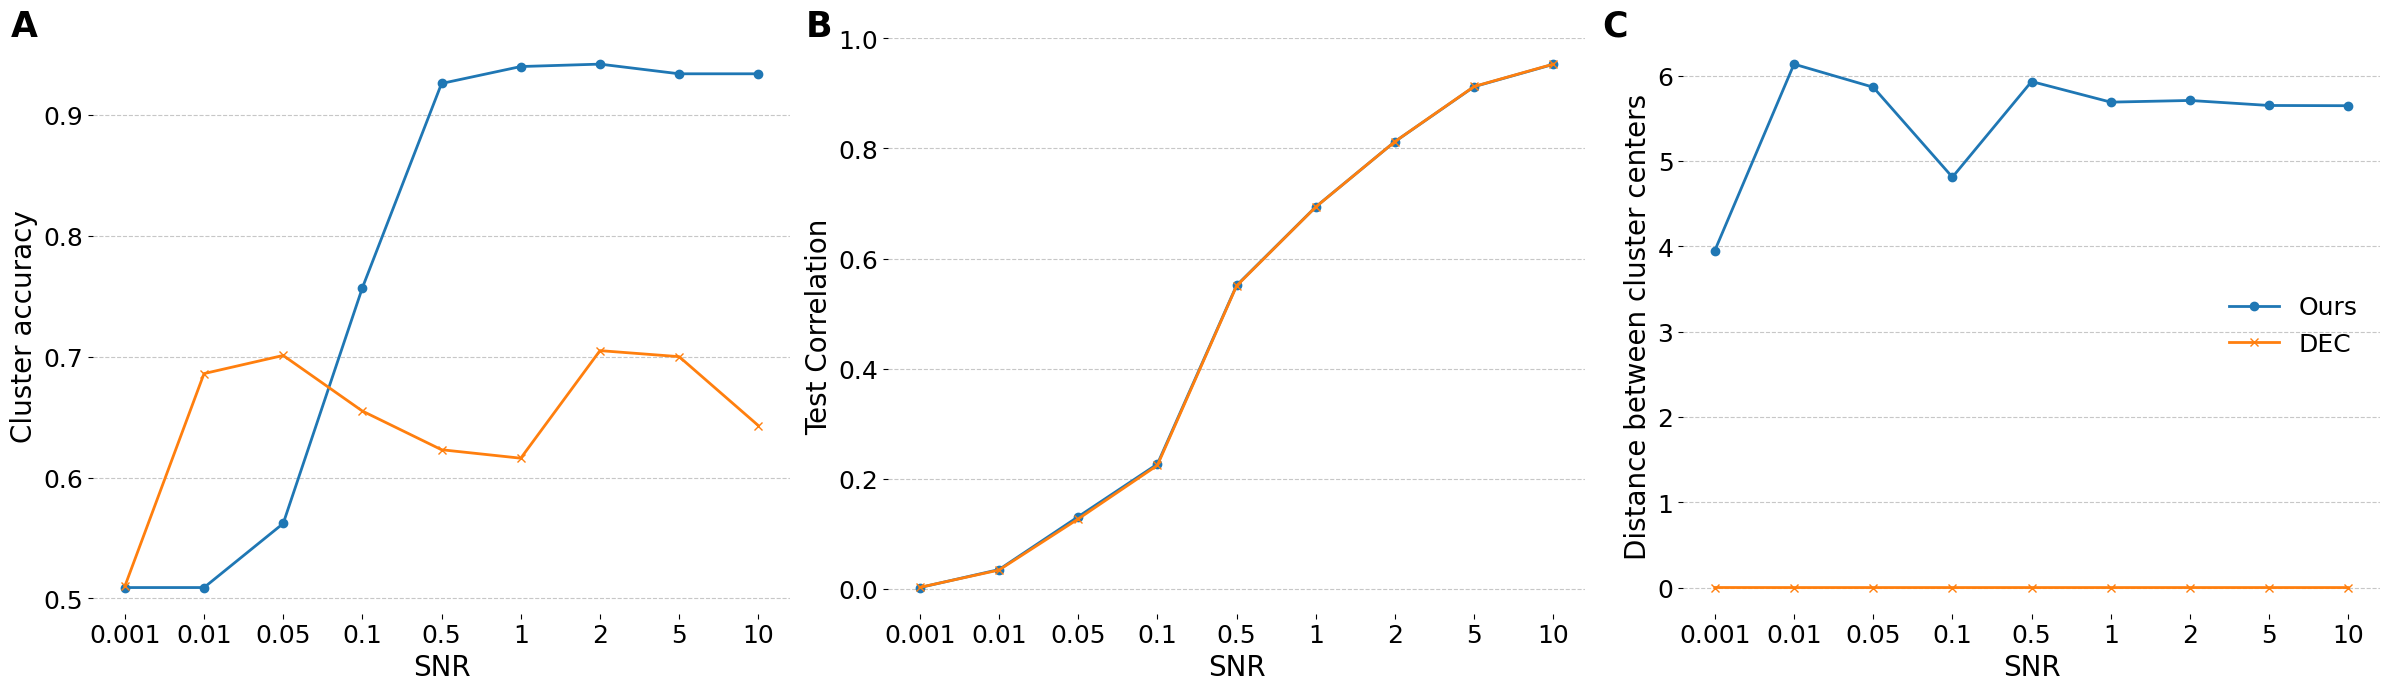

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Panel A — Classification Accuracy
# -------------------------
true_labels = np.concatenate((np.zeros(700), np.ones(300)))  # true underlying labels

accuracies_ours = []
accuracies_dec = []

for preds in [predictions_ours, predictions_DEC]:  # assuming these are lists per SNR
    acc_per_snr = []
    for p in preds:
        zeros = np.sum(p == 0)
        ones = np.sum(p == 1)

        # Compute accuracy allowing for label swap
        correct_normal = np.sum(p == true_labels)
        correct_swapped = np.sum(1 - p == true_labels)
        acc = max(correct_normal, correct_swapped) / len(true_labels)
        acc_per_snr.append(acc)
    if preds is predictions_ours:
        accuracies_ours = acc_per_snr
    else:
        accuracies_dec = acc_per_snr

snrs = np.array(snrs)
differences_ours = []
differences_dec = []

for snr_idx in range(len(snrs)):
    centers_ours = cluster_centers_list_ours[snr_idx][-1]  # last center set at this SNR
    centers_dec = cluster_centers_list_DEC[snr_idx][-1]

    diff_ours = np.linalg.norm(centers_ours[0]- centers_ours[1])
    diff_dec = np.linalg.norm(centers_dec[0]- centers_dec[1])

    differences_ours.append(diff_ours)
    differences_dec.append(diff_dec)

# -------------------------
# Panel B — Correlations
# (already computed as best_corr_ours and best_corr_DEC)
# -------------------------

# -------------------------
# Panel C — Cluster center distance
# (you already have differences_ours, differences_dec computed)
# -------------------------

# Make subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fontsize = 20

# Panel A
axes[0].plot(np.arange(len(snrs)), accuracies_ours, marker='o', linewidth=2, label='Ours')
axes[0].plot(np.arange(len(snrs)), accuracies_dec, marker='x', linewidth=2, label='DEC')
axes[0].set_xticks(np.arange(len(snrs)))
axes[0].set_xticklabels([f"{snr:.2g}" for snr in snrs], fontsize=fontsize-2)
axes[0].set_xlabel("SNR", fontsize=fontsize)
axes[0].set_ylabel("Cluster accuracy", fontsize=fontsize)
#axes[0].legend(frameon=False, fontsize=fontsize-2)
axes[0].tick_params(axis='both', labelsize=fontsize-2)

# Panel B
axes[1].plot(np.arange(len(snrs)), best_corr_ours, marker='o', linewidth=2, label='Ours')
axes[1].plot(np.arange(len(snrs)), best_corr_DEC, marker='x', linewidth=2, label='DEC')
axes[1].set_xticks(np.arange(len(snrs)))
axes[1].set_xticklabels([f"{snr:.2g}" for snr in snrs], fontsize=fontsize-2)
axes[1].set_xlabel("SNR", fontsize=fontsize)
axes[1].set_ylabel("Test Correlation", fontsize=fontsize)
#axes[1].legend(frameon=False, fontsize=fontsize-2)
axes[1].tick_params(axis='both', labelsize=fontsize-2)

# Panel C
axes[2].plot(np.arange(len(snrs)), differences_ours, marker='o', linewidth=2, label='Ours')
axes[2].plot(np.arange(len(snrs)), differences_dec, marker='x', linewidth=2, label='DEC')
axes[2].set_xticks(np.arange(len(snrs)))
axes[2].set_xticklabels([f"{snr:.2g}" for snr in snrs], fontsize=fontsize-2)
axes[2].set_xlabel("SNR", fontsize=fontsize)
axes[2].set_ylabel("Distance between cluster centers", fontsize=fontsize)
axes[2].legend(frameon=False, fontsize=fontsize-2)
axes[2].tick_params(axis='both', labelsize=fontsize-2)

for i in range(3):
    for spine in ['top', 'left', 'right', 'bottom']:
        axes[i].spines[spine].set_visible(False)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Add subplot labels
labels = ['A', 'B', 'C']
for ax, label in zip(axes, labels):
    ax.text(-0.08, 1.05, label, transform=ax.transAxes,
            fontsize=fontsize+5, fontweight='bold', va='top', ha='right')

plt.tight_layout()

import os
save_path = os.path.join('..', 'plots', 'paper_plots', 'SNR.pdf')
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()


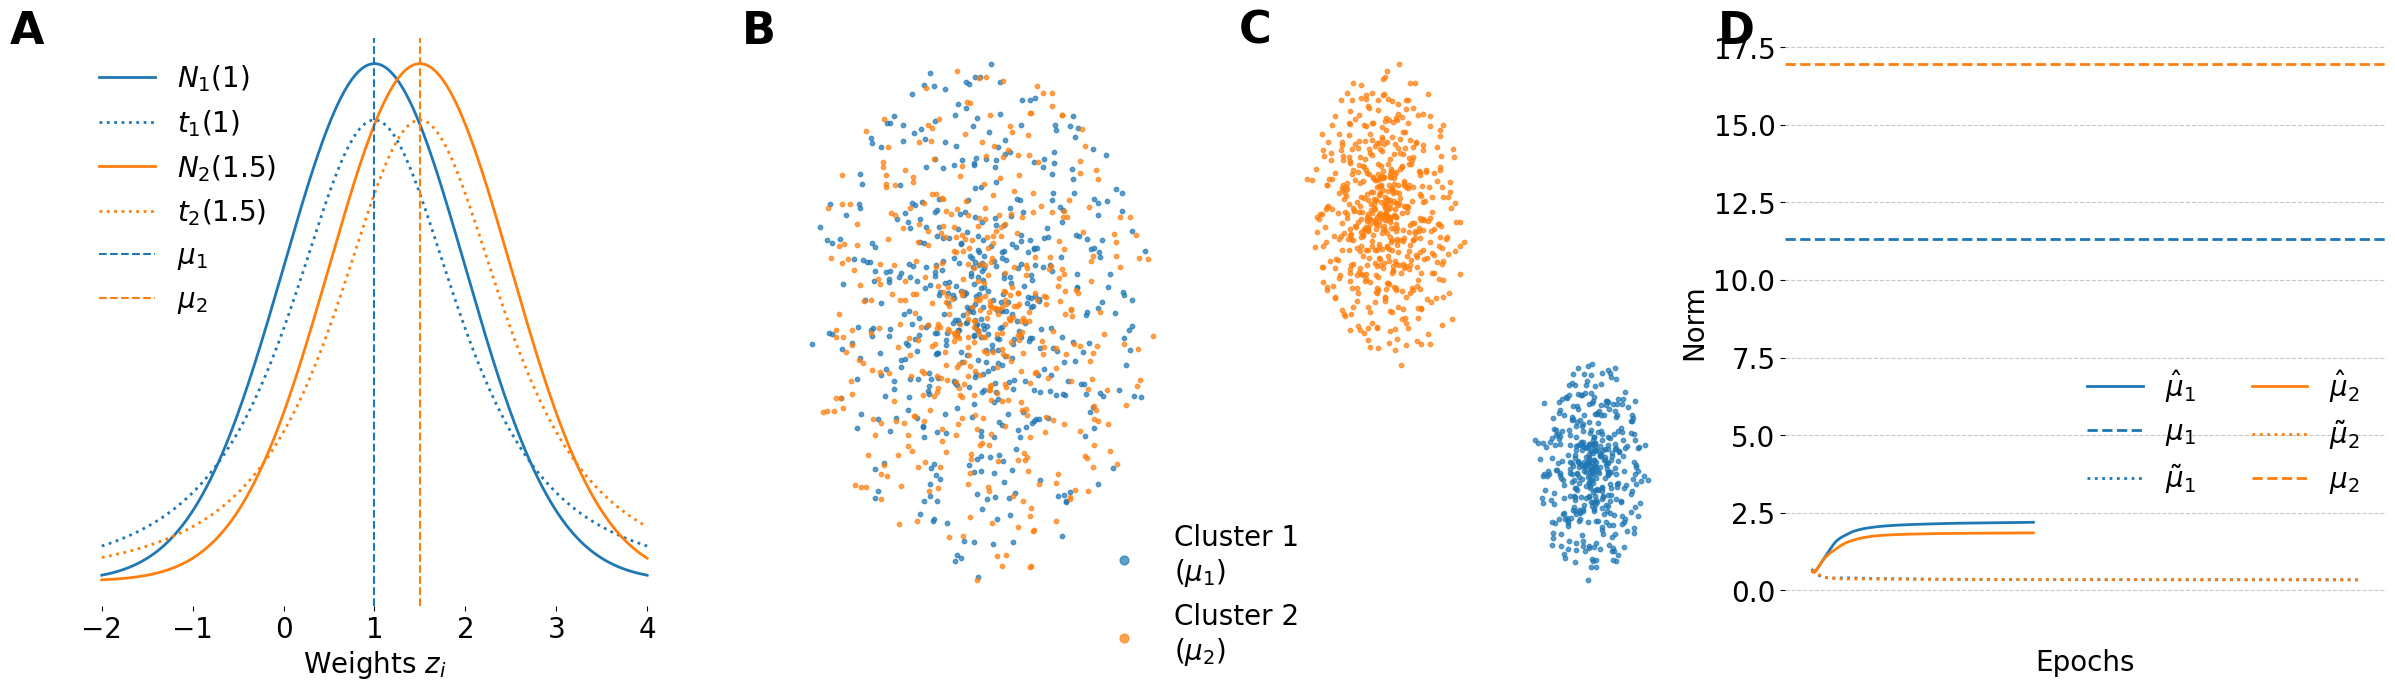

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm
from sklearn.manifold import TSNE  # make sure sklearn is installed


# ================================================
# Panel A: Distributions
# ================================================
def plot_distributions(ax, fontsize):
    x = np.linspace(-2, 4, 1000)
    n1 = norm(loc=1, scale=1)
    n2 = norm(loc=1.5, scale=1)
    df = 2.1
    t1 = t(df, loc=1.0, scale=1)
    t2 = t(df, loc=1.5, scale=1)

    blue = '#1f77b4'
    orange = '#ff7f0e'
 
    ax.plot(x, n1.pdf(x), label=r"$N_1(1)$", color=blue, lw=2)
    ax.plot(x, t1.pdf(x), label=r"$t_1(1)$", color=blue, ls='dotted', lw=2)
    ax.plot(x, n2.pdf(x), label=r"$N_2(1.5)$", color=orange, lw=2)
    ax.plot(x, t2.pdf(x), label=r"$t_2(1.5)$", color=orange, ls='dotted', lw=2)

    ax.set_xlabel(r"Weights $z_i$", fontsize=fontsize)
    ax.set_yticks([])
    ax.axvline(x=1, color=blue, linestyle='--', label=r"$\mu_1$")
    ax.axvline(x=1.5, color=orange, linestyle='--', label=r"$\mu_2$")
    ax.tick_params(axis='x', labelsize=fontsize)
    ax.legend(frameon=False, loc='upper left', fontsize=fontsize)

    for spine in ['top', 'left', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

# ================================================
# Panel B and C: t-SNE Scatter
# ================================================
def plot_tsne(ax, features, predictions, cluster_centers, cluster_number, fontsize, include_legend=True):
    n = features.shape[0]
    perplexity = n / 100
    lr = 1
    early_exaggeration = n / 10

    combined_data = np.vstack([features, cluster_centers])  # Stack features with centers

    colors = ['#1f77b4', '#ff7f0e']
    # Apply t-SNE to combined data
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=lr,
        early_exaggeration=early_exaggeration,
        random_state=42
    )
    embedded_data = tsne.fit_transform(combined_data)
    embedded_points = embedded_data[:n]

    for value in range(cluster_number):
        cluster_mask = predictions == value
        ax.scatter(
            embedded_points[cluster_mask, 0],
            embedded_points[cluster_mask, 1],
            label=f'Cluster {value+1}\n($\\mu_{value+1}$)',
            alpha=0.7,
            s=10
        )

    ax.set_xticks([])
    ax.set_yticks([])

    # Shrink plot a little so legend does not overlap
    pos = ax.get_position()
    #ax.set_position([pos.x0, pos.y0, pos.width*1.2, pos.height*1.2])  # shrink width & height slightly

    for spine in ['top', 'left', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)


# ================================================
# Panel D: Cluster center distances over time
# ================================================
def plot_cluster_distance(ax, cluster_centers_list_ours, cluster_centers_list_DEC, cluster_number,fontsize):
    time_ours = cluster_centers_list_ours[0].shape[0]
    time_DEC = cluster_centers_list_DEC[0].shape[0]
    cluster_centers_distances_ours = np.zeros((time_ours, cluster_number))
    cluster_centers_distances_DEC = np.zeros((time_DEC, cluster_number))


    for batch in range(time_ours):
        cluster_centers_distances_ours[batch][:] = np.linalg.norm(cluster_centers_list_ours[0][batch], axis=1)

    for batch in range(time_DEC):
        cluster_centers_distances_DEC[batch][:] = np.linalg.norm(cluster_centers_list_DEC[0][batch], axis=1)

    colors = ['#1f77b4', '#ff7f0e']

    for cluster_idx in range(cluster_number):
        ax.plot(range(time_ours),
                cluster_centers_distances_ours[:time_ours, cluster_idx],
                label=fr'$\hat\mu_{cluster_idx+1}$',
                linewidth=2,
                color=colors[cluster_idx])
        if cluster_idx == 0:
            ax.axline((0, np.sqrt(128)), color=colors[0], linestyle="--", label=fr"$\mu_1$", slope=0, linewidth=2)
        ax.plot(range(time_DEC),
                cluster_centers_distances_DEC[:time_DEC, cluster_idx],
                label=fr'$\tilde\mu_{cluster_idx+1}$',
                linewidth=2,
                linestyle='dotted',
                color=colors[cluster_idx])

    ax.axline((0, np.sqrt(128*1.5**2)), color=colors[1], linestyle="--", label=fr"$\mu_2$", slope=0, linewidth=2)
    ax.set_xlabel('Epochs', fontsize=fontsize)
    ax.set_ylabel('Norm', fontsize=fontsize)
    #ax.set_xticks([1],color='white',fontsize=fontsize)
    ax.tick_params(axis='x', colors='white', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.legend(loc='lower right', frameon=False, fontsize=fontsize, ncol =2, bbox_to_anchor =(1,0.15))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    for spine in ['top', 'left', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

# ================================================
# Assemble the figure
# ================================================
width_ratio = [1.6,1,1,1.6]
fig, axes = plt.subplots(1, 4, figsize=(24, 7), 
    gridspec_kw={'width_ratios': width_ratio})
fontsize = 20
cluster_number = 2

plot_distributions(axes[0],fontsize)
plot_tsne(axes[2], features_ours[0], predictions_ours[0], cluster_centers_list_ours[0][-1], cluster_number,fontsize=fontsize,include_legend=False)
plot_tsne(axes[1], features_DEC[0], predictions_DEC[0], cluster_center_list_DEC[0][-1], cluster_number,fontsize =fontsize,include_legend=True)
plot_cluster_distance(axes[3], cluster_centers_list_ours, cluster_centers_list_DEC, cluster_number,fontsize =fontsize)

fig.legend(
    handles=axes[1].get_legend_handles_labels()[0],
    labels=axes[1].get_legend_handles_labels()[1],
    frameon=False,
    fontsize=fontsize,
    loc='lower center',
    ncol=1,
    markerscale=2
)

labels = ['A', 'B', 'C', 'D']
for ax, label in zip(axes, labels):
    ax.text(-0.05, 1.05, label, transform=ax.transAxes,
            fontsize=32, fontweight='bold', va='top', ha='right')


plt.tight_layout()
import os
save_path = os.path.join('..', 'plots', 'paper_plots', 'toy_example_neuro.pdf')
#plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()